Initial shape: (54810, 9)
Feature count: 12
Model loaded successfully.
SHAP values computed.


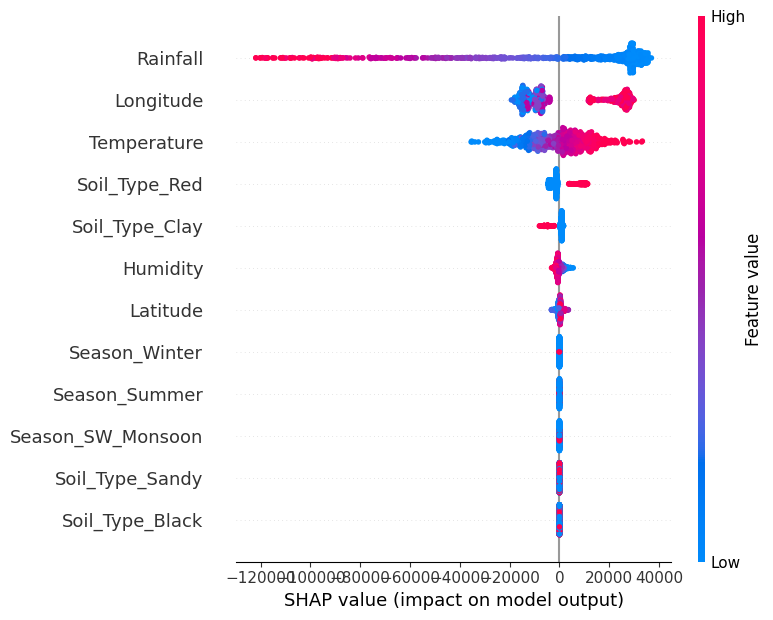

In [3]:
import pandas as pd
import os
import joblib
import shap
import matplotlib.pyplot as plt

# -----------------------------------------
# STEP 1 — Load Final Dataset
# -----------------------------------------

project_root = os.path.abspath("..")
data_folder = os.path.join(project_root, "data")

final_path = os.path.join(data_folder, "final_spatial_irrigation_dataset.csv")
df = pd.read_csv(final_path)

print("Initial shape:", df.shape)

# Fix Water_Liters if accidentally saved as string with brackets
df["Water_Liters"] = (
    df["Water_Liters"]
    .astype(str)
    .str.replace("[", "", regex=False)
    .str.replace("]", "", regex=False)
    .astype(float)
)

# -----------------------------------------
# STEP 2 — Encode Categorical Variables
# -----------------------------------------

df = pd.get_dummies(df, columns=["Season", "Soil_Type"], drop_first=True)

X = df.drop(["Date", "Water_Liters"], axis=1)

print("Feature count:", X.shape[1])

# -----------------------------------------
# STEP 3 — Load Trained Model
# -----------------------------------------

model_path = os.path.join(project_root, "models", "best_spatial_model.pkl")
model = joblib.load(model_path)

print("Model loaded successfully.")

# -----------------------------------------
# STEP 4 — Create SHAP Explainer
# -----------------------------------------

explainer = shap.TreeExplainer(model)

# Use sample for faster computation
X_sample = X.sample(1000, random_state=42)

# IMPORTANT: Disable strict additivity check
shap_values = explainer.shap_values(X_sample, check_additivity=False)

print("SHAP values computed.")

# -----------------------------------------
# STEP 5 — Global Feature Importance
# -----------------------------------------

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_sample, show=False)
plt.tight_layout()
plt.show()

# -----------------------------------------
# STEP 6 — Local Explanation (Single Prediction)
# -----------------------------------------

sample_instance = X_sample.iloc[0:1]
shap_value_single = explainer.shap_values(sample_instance, check_additivity=False)

shap.initjs()

shap.force_plot(
    explainer.expected_value,
    shap_value_single[0],
    sample_instance
)

In [4]:
import numpy as np

# Compute mean absolute SHAP value per feature
feature_importance = pd.DataFrame({
    "Feature": X_sample.columns,
    "Mean_SHAP_Value": np.abs(shap_values).mean(axis=0)
})

feature_importance = feature_importance.sort_values(
    by="Mean_SHAP_Value",
    ascending=False
)

print(feature_importance.head(10))

              Feature  Mean_SHAP_Value
4            Rainfall     32900.132812
1           Longitude     15894.475586
2         Temperature      9648.034180
10      Soil_Type_Red      3370.656494
9      Soil_Type_Clay      1431.722290
3            Humidity      1038.606323
0            Latitude       627.283020
7       Season_Winter         8.118384
6       Season_Summer         5.213564
5   Season_SW_Monsoon         3.298102


In [5]:
feature_importance.head(5)

,Feature,Mean_SHAP_Value
4,Rainfall,32900.132812
1,Longitude,15894.475586
2,Temperature,9648.034180
10,Soil_Type_Red,3370.656494
9,Soil_Type_Clay,1431.722290


In [8]:
# Compute SHAP interaction values
interaction_values = explainer.shap_interaction_values(X_sample)

print("Interaction values computed.")

Interaction values computed.


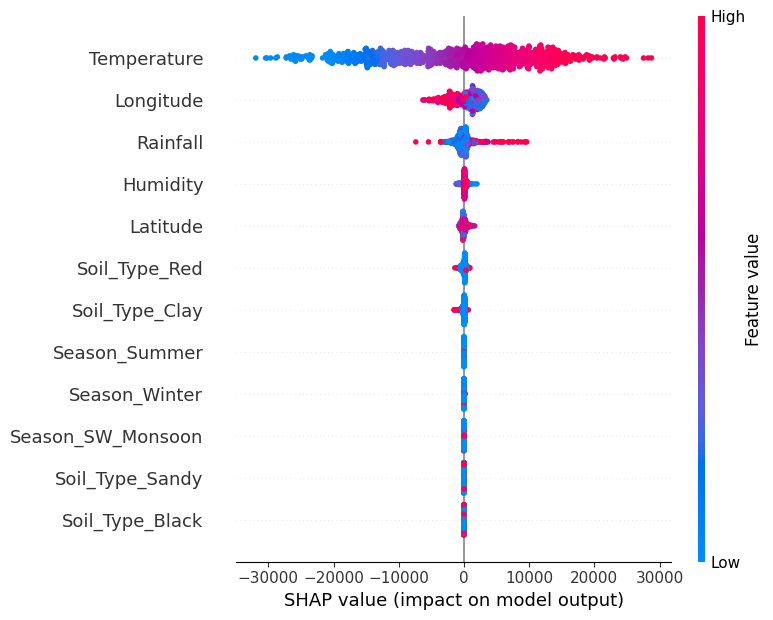

In [9]:
feature_names = X_sample.columns.tolist()

# Temperature interaction
temp_index = feature_names.index("Temperature")

shap.summary_plot(
    interaction_values[:, temp_index, :],
    X_sample,
    show=False
)

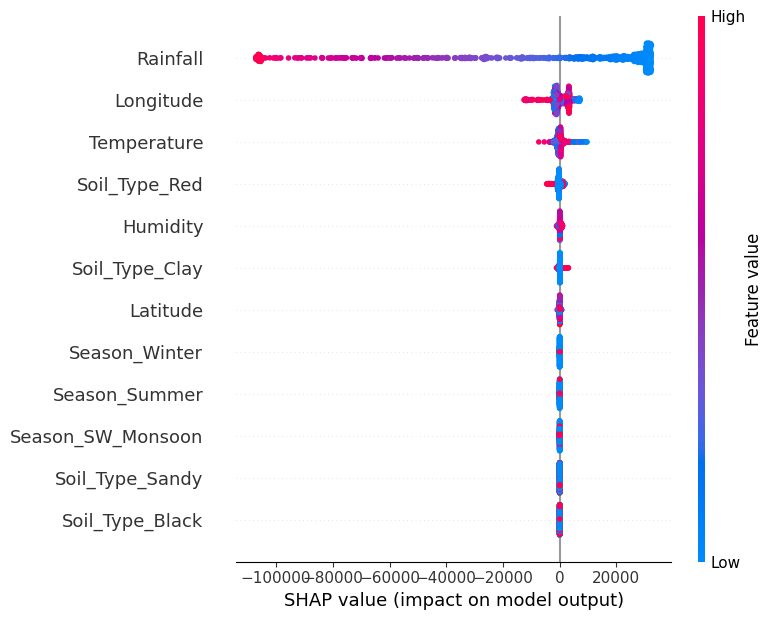

In [10]:
rain_index = feature_names.index("Rainfall")

shap.summary_plot(
    interaction_values[:, rain_index, :],
    X_sample,
    show=False
)

In [11]:
import numpy as np
import pandas as pd

feature_names = X_sample.columns.tolist()

# Mean absolute interaction strength
mean_interactions = np.abs(interaction_values).mean(axis=0)

interaction_df = pd.DataFrame(
    mean_interactions,
    index=feature_names,
    columns=feature_names
)

# Remove self-interactions (diagonal)
for i in range(len(feature_names)):
    interaction_df.iloc[i, i] = 0

# Get top 10 strongest interaction pairs
top_interactions = (
    interaction_df.stack()
    .sort_values(ascending=False)
    .drop_duplicates()
    .head(10)
)

top_interactions

Longitude      Rainfall         2314.337402
Temperature    Longitude        1729.772949
Longitude      Temperature      1729.772461
Soil_Type_Red  Longitude         986.262756
Longitude      Soil_Type_Red     986.262146
Temperature    Rainfall          787.371033
Rainfall       Temperature       787.370361
Soil_Type_Red  Rainfall          621.683228
Rainfall       Soil_Type_Red     621.682556
Longitude      Latitude          348.598969
dtype: float32

In [12]:
soil_cols = [col for col in feature_names if "Soil" in col]
climate_cols = ["Temperature", "Humidity", "Rainfall"]

soil_climate_interactions = {}

for s in soil_cols:
    for c in climate_cols:
        soil_climate_interactions[f"{c} × {s}"] = interaction_df.loc[c, s]

soil_climate_df = pd.Series(soil_climate_interactions).sort_values(ascending=False)

soil_climate_df

Rainfall × Soil_Type_Red         621.682556
Temperature × Soil_Type_Red      209.297913
Rainfall × Soil_Type_Clay        185.919647
Temperature × Soil_Type_Clay     131.123825
Humidity × Soil_Type_Red          98.185814
Humidity × Soil_Type_Clay         41.919922
Temperature × Soil_Type_Black      0.000000
Humidity × Soil_Type_Black         0.000000
Rainfall × Soil_Type_Black         0.000000
Temperature × Soil_Type_Sandy      0.000000
Humidity × Soil_Type_Sandy         0.000000
Rainfall × Soil_Type_Sandy         0.000000
dtype: float32

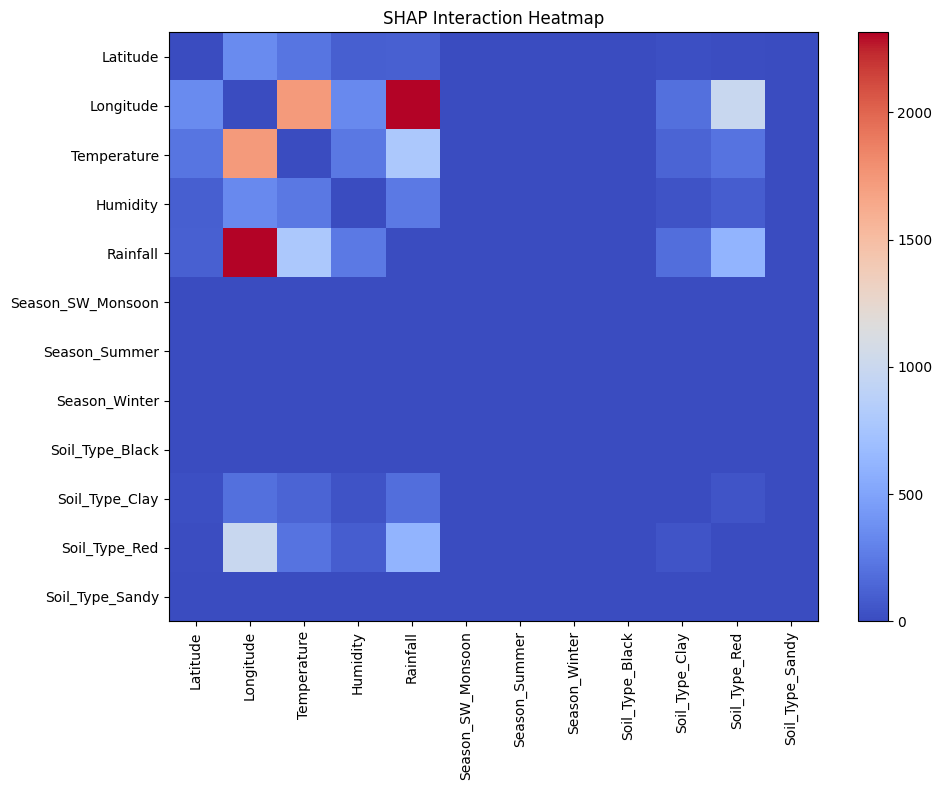

In [14]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10, 8))
plt.imshow(interaction_df.values, cmap='coolwarm', aspect='auto')
plt.colorbar()

plt.xticks(range(len(interaction_df.columns)), interaction_df.columns, rotation=90)
plt.yticks(range(len(interaction_df.index)), interaction_df.index)

plt.title("SHAP Interaction Heatmap")
plt.tight_layout()
plt.show()